## Exercício Semana 2 - Capacitação Analytica

# Importações das Bibliotecas Python

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importação do .csv

In [3]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")

## Entregável 1 - Numpy

# A - CRIANDO ARRAYS

In [4]:
print(df.columns)

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='str')


In [5]:
preco = df['preco_unitario'].to_numpy()
custo = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto = df['desconto_pct'].to_numpy()
receita = df['receita_total'].to_numpy()
frete = df['frete'].to_numpy()

# B - CÁLCULOS COM OPERAÇÕES VETORIZADAS

In [6]:
#1 Valor bruto da venda
valor_bruto = preco * quantidade

In [7]:
#2 Valor do desconto 
valor_desconto = valor_bruto * desconto

In [8]:
#3 Custo total
custo_total = custo * quantidade

In [9]:
#4 Lucro estimado
lucro_estimado = valor_bruto - valor_desconto - custo_total - frete

# C - MÁSCARAS BOOLEANAS

In [10]:
#1 Vendas com receita acima da média
média_receita = np.mean(receita)
receita_acima_da_média = receita[receita > média_receita]

In [11]:
#2 Vendas com prejuízo
vendas_com_prejuizo = df[receita < custo_total + frete]

In [12]:
#3 Vendas com desconto alto
desconto_alto = df[desconto > 0.30]

In [13]:
#Máscaras
print("Vendas com receita acima da média:", receita_acima_da_média)
print("Vendas com prejuízo:", vendas_com_prejuizo)
print("Vendas com desconto alto:", desconto_alto)

Vendas com receita acima da média: [6933.48 2167.48 7945.96 ... 3369.62 1960.18 3795.73]
Vendas com prejuízo:        data_venda  mes          cidade canal_venda    categoria  \
4      2022-03-13    3  Belo Horizonte  App Mobile     Esportes   
8      2022-05-02    5       São Paulo    Site Web  Alimentação   
24     2022-07-11    7          Recife  App Mobile    Vestuário   
40     2023-07-17    7       Fortaleza    Site Web  Alimentação   
41     2023-07-21    7    Porto Alegre  App Mobile  Alimentação   
...           ...  ...             ...         ...          ...   
37587  2023-12-31    2        Salvador    Site Web       Livros   
37589  2023-12-31    4  Rio de Janeiro  App Mobile  Eletrônicos   
37592  2023-12-31    6  Belo Horizonte    Site Web    Vestuário   
37594  2023-12-31    2          Manaus    Site Web  Alimentação   
37611  2023-12-31    9        Salvador    Site Web       Livros   

               produto       vendedor fidelidade_cliente  preco_unitario  \
4        

# D - AGREGAÇÕES

In [14]:
#1 Receita média
print("Receita média:", np.mean(receita))

Receita média: 1891.6881729005502


In [15]:
#2 Maior receita
print("Maior receita:", np.max(receita))

Maior receita: 58430.28


In [16]:
#3 Menor receita
print("Menor receita:", np.min(receita))

Menor receita: 3.7


In [17]:
#4 Lucro média
print("Lucro médio:", np.mean(lucro_estimado))

Lucro médio: nan


In [18]:
#5 Quantidade de vendas com prejuízo
quantidade_vendas_prejuizo = len(vendas_com_prejuizo)
print("Quantidade de vendas com prejuízo:", quantidade_vendas_prejuizo)

Quantidade de vendas com prejuízo: 5857


## Entregável 2 - Pandas

# A - PRIMEIRO OLHAR NO DATASET

In [19]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [20]:
df.shape

(37617, 21)

Quantas linhas e colunas existem?
Existem: 37617 linhas e 21 colunas

In [21]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

Existem dados faltantes?
Sim, existem

In [22]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

Quantas colunas parecem categóricas?
str e bool

Quantas colunas parecem numéricas?
float64 e int64

# B - LIMPEZA E TRATAMENTO

In [261]:
df["cidade"] = df["cidade"].str.strip().str.lower()


In [296]:
df["cidade"] = df["cidade"].replace({
    "sp": "são paulo",
    "s. paulo": "são paulo",
    "sao paulo": "são paulo",

    "rj": "rio de janeiro",
    "rio": "rio de janeiro",

    "bh": "belo horizonte",
    "b. horizonte": "belo horizonte",

    "slavador": "salvador",

    "curtiba": "curitiba"
})

In [297]:
print(sorted(df["cidade"].unique()))

['belo horizonte', 'curitiba', 'fortaleza', 'goiânia', 'manaus', 'porto alegre', 'recife', 'rio de janeiro', 'salvador', 'são paulo']


In [298]:
df["categoria"] = df["categoria"].str.strip().str.title()

df["canal_venda"] = df["canal_venda"].str.strip().str.title()

df["produto"] = df["produto"].str.strip().str.title()

In [299]:
#1 Converta a coluna de data para o tipo datetime
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [300]:
print(df["data_venda"].head())

0   2022-04-13
1   2023-12-03
2   2022-09-28
3   2022-04-17
4   2022-03-13
Name: data_venda, dtype: datetime64[us]


In [301]:
#2 Padronize pelo menos uma coluna categórica que tenha valores escritos de formas diferentes
df["canal_venda"] = df["canal_venda"].str.title()
df["canal_venda"] = df["canal_venda"].fillna("Desconhecido")


In [302]:
print(df["canal_venda"].value_counts())

canal_venda
Site Web        11315
App Mobile      11258
Loja Física      7467
Marketplace      5604
Televendas       1861
Desconhecido       50
Siteweb            31
Loja Fisica        31
Name: count, dtype: int64


In [303]:
#3 Trate alguns dados faltantes de forma adequada
df["frete"] = df["frete"].fillna(df["frete"].mean())
df["avaliacao_cliente"] = df["avaliacao_cliente"].fillna(
    df["avaliacao_cliente"].mean()
)
df["prazo_entrega_dias"] = df["prazo_entrega_dias"].fillna(
    df["prazo_entrega_dias"].median()
)
df["margem_pct"] = df["margem_pct"].fillna(
    df["margem_pct"].mean()
)

Foram tratados os valores ausentes utilizando média para variáveis contínuas e mediana para prazo de entrega. A coluna 'canal_venda' foi padronizada e valores ausentes receberam a categoria "Desconhecido".

# C - CRIAÇÃO DE NOVAS COLUNAS

In [304]:
#1 Ano da venda
df['ano_venda'] = df['data_venda'].dt.year

In [305]:
print(df['ano_venda'].value_counts())

ano_venda
2023    19015
2022    18602
Name: count, dtype: int64


In [306]:
#2 mês da venda
df['mes_venda'] = df['data_venda'].dt.month

In [307]:
print(df['mes_venda'].value_counts(ascending=True))

mes_venda
2     2827
6     2967
11    3087
9     3106
5     3138
4     3158
7     3194
3     3205
12    3213
8     3218
10    3240
1     3264
Name: count, dtype: int64


In [308]:
#3 lucro total 
df['lucro_total'] = (df['preco_unitario'] - df['custo_unitario']) * df['quantidade']

In [309]:
print(df['lucro_total'].head())

0    1776.40
1     261.65
2     205.94
3     630.63
4      26.67
Name: lucro_total, dtype: float64


In [310]:
#4 Receita líquida
df['receita_liquida'] = df['receita_total'] - df['frete']

In [311]:
print(df['receita_liquida'].head())

0    6924.800000
1     900.394263
2    1050.520000
3    1571.940000
4      84.750000
Name: receita_liquida, dtype: float64


In [312]:
#5 Faixa da receita
df["faixa_receita"] = df["receita_total"].apply(lambda x: "Alta" if x >= 3000 else "Baixa")

In [313]:
print(df['faixa_receita'].head())

0     Alta
1    Baixa
2    Baixa
3    Baixa
4    Baixa
Name: faixa_receita, dtype: str


# D - FILTRO

In [314]:
#1 Quais vendas tiveram receita acima de determinado valor?
receita_alta = df[df["receita_total"] > 3000]

In [315]:
print(receita_alta.head())

   data_venda  mes          cidade  canal_venda    categoria     produto  \
0  2022-04-13    4  rio de janeiro   App Mobile  Eletrônicos    Notebook   
15 2022-10-04    4        salvador  Marketplace  Eletrônicos  Smartphone   
17 2022-11-05    5  belo horizonte   App Mobile  Eletrônicos  Smartwatch   
20 2022-10-12   12          recife     Site Web  Eletrônicos  Smartphone   
21 2023-07-05    5       são paulo  Loja Física  Eletrônicos  Smartwatch   

       vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
0   Bruno Souza           Diamante          739.39          561.75  ...   
15     Ana Lima             Bronze         1213.88          843.05  ...   
17  Elisa Costa              Prata          732.37          536.37  ...   
20   Inês Nunes              Prata          603.40          394.18  ...   
21   Gabi Alves             Bronze          892.83          660.58  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
0                  5.

In [316]:
#2 Quais vendas tiveram devolução?
devolucoes = df[df["devolucao"] == True]

In [317]:
print(devolucoes.head())

   data_venda  mes     cidade  canal_venda    categoria       produto  \
1  2023-12-03    3     manaus     Site Web    Vestuário      Camiseta   
2  2022-09-28    9    goiânia   App Mobile    Vestuário         Tênis   
7  2023-07-09    9     manaus   App Mobile  Alimentação  Mel Orgânico   
18 2023-10-24   10     manaus     Site Web    Vestuário      Camiseta   
21 2023-07-05    5  são paulo  Loja Física  Eletrônicos    Smartwatch   

        vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
1    Elisa Costa             Bronze          187.48          135.15  ...   
2    João Vieira             Bronze           76.11           61.40  ...   
7     Inês Nunes              Prata           35.72           21.62  ...   
18  Carla Mendes              Prata           65.73           41.26  ...   
21    Gabi Alves             Bronze          892.83          660.58  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
1                 19.0       True

In [318]:
#3 Quais vendas pertencem a uma categoria específica?
eletronicos = df[df["categoria"] == "Eletrônicos"]

In [319]:
print(eletronicos.head())

   data_venda  mes          cidade  canal_venda    categoria     produto  \
0  2022-04-13    4  rio de janeiro   App Mobile  Eletrônicos    Notebook   
15 2022-10-04    4        salvador  Marketplace  Eletrônicos  Smartphone   
17 2022-11-05    5  belo horizonte   App Mobile  Eletrônicos  Smartwatch   
20 2022-10-12   12          recife     Site Web  Eletrônicos  Smartphone   
21 2023-07-05    5       são paulo  Loja Física  Eletrônicos  Smartwatch   

       vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
0   Bruno Souza           Diamante          739.39          561.75  ...   
15     Ana Lima             Bronze         1213.88          843.05  ...   
17  Elisa Costa              Prata          732.37          536.37  ...   
20   Inês Nunes              Prata          603.40          394.18  ...   
21   Gabi Alves             Bronze          892.83          660.58  ...   

    prazo_entrega_dias  devolucao  entrega_no_prazo  alta_temporada  \
0                  5.

resultado dos filtros:
Foram identificadas vendas com receita superior a R$ 3.000, vendas devolvidas e todas as vendas da categoria Eletrônicos.

# E - AGRUPAMENTOS COM GROUPBY

In [320]:
#1 Qual categoria teve maior receita total?
df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [321]:
#2 Qual canal de venda teve maior quantidade de vendas?
df.groupby("canal_venda")["quantidade"].sum().sort_values(ascending=False)

canal_venda
Site Web        84860
App Mobile      83839
Loja Física     56498
Marketplace     41707
Televendas      13726
Desconhecido      373
Siteweb           231
Loja Fisica       207
Name: quantidade, dtype: int64

In [322]:
#3 Qual cidade teve maior receita?
df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)

cidade
recife            7662241.79
manaus            7459161.23
fortaleza         7242081.82
goiânia           7178113.69
porto alegre      7048428.17
curitiba          6993175.07
salvador          6918656.01
belo horizonte    6914747.61
rio de janeiro    6880176.34
são paulo         6862852.27
Name: receita_total, dtype: float64

In [323]:
#4 Qual categoria teve maior lucro?
df.groupby("categoria")["lucro_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    12450472.71
Esportes        3176095.56
Vestuário       1876276.96
Livros          1230691.06
Alimentação      917614.87
Name: lucro_total, dtype: float64

# F - MERGE

In [324]:
regioes = pd.DataFrame({
    "cidade": [
        "Rio de Janeiro",
        "São Paulo",
        "Belo Horizonte",
        "Salvador",
        "Fortaleza",
        "Curitiba",
        "Manaus",
        "Recife",
        "Goiânia",
        "Porto Alegre"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Nordeste",
        "Nordeste",
        "Sul",
        "Norte",
        "Nordeste",
        "Centro-Oeste",
        "Sul"
    ]
})

In [325]:
df_merge = df.merge(regioes, on="cidade", how="left")

In [326]:
df_merge.groupby("regiao")["receita_total"].sum()

Series([], Name: receita_total, dtype: float64)

In [331]:
print(regioes)

           cidade        regiao
0  Rio de Janeiro       Sudeste
1       São Paulo       Sudeste
2  Belo Horizonte       Sudeste
3        Salvador      Nordeste
4       Fortaleza      Nordeste
5        Curitiba           Sul
6          Manaus         Norte
7          Recife      Nordeste
8         Goiânia  Centro-Oeste
9    Porto Alegre           Sul


Após relacionar cada cidade com sua respectiva região, foi possível analisar a receita total por região brasileira

## ENTREGÁVEL 3 - SEABORN

# A - GRÁFICO DE BARRAS

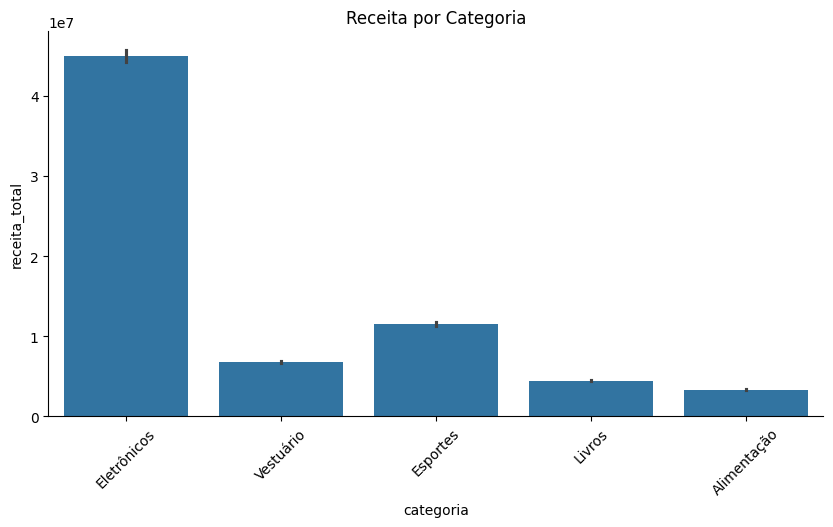

In [332]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="categoria",
    y="receita_total",
    estimator="sum"
)

plt.xticks(rotation=45)

plt.title("Receita por Categoria")

sns.despine()

plt.show()

Observa-se que algumas categorias concentram maior faturamento do que outras.

# B - GRÁFICO DE LINHA

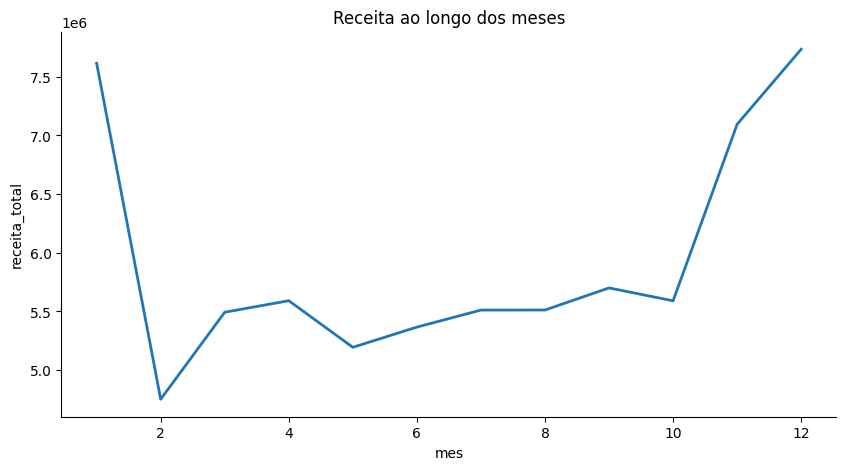

In [333]:
receita_mes = df.groupby("mes")["receita_total"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=receita_mes,
    x="mes",
    y="receita_total",
    linewidth=2
)

plt.title("Receita ao longo dos meses")

sns.despine()

plt.show()

A receita apresenta variações ao longo dos meses, indicando possíveis efeitos sazonais.

# C - GRÁFICO DE DISPERSÃO

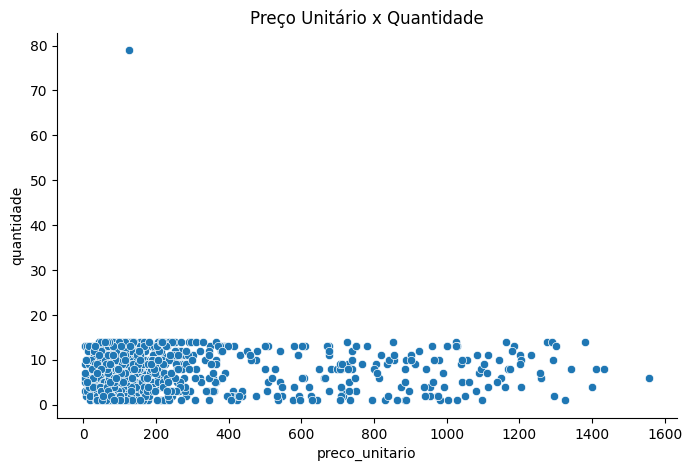

In [334]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(1000),
    x="preco_unitario",
    y="quantidade"
)

plt.title("Preço Unitário x Quantidade")

sns.despine()

plt.show()

O gráfico mostra a relação entre preço unitário e quantidade vendida para uma amostra do conjunto de dados.

# D - MAPA DE CALOR

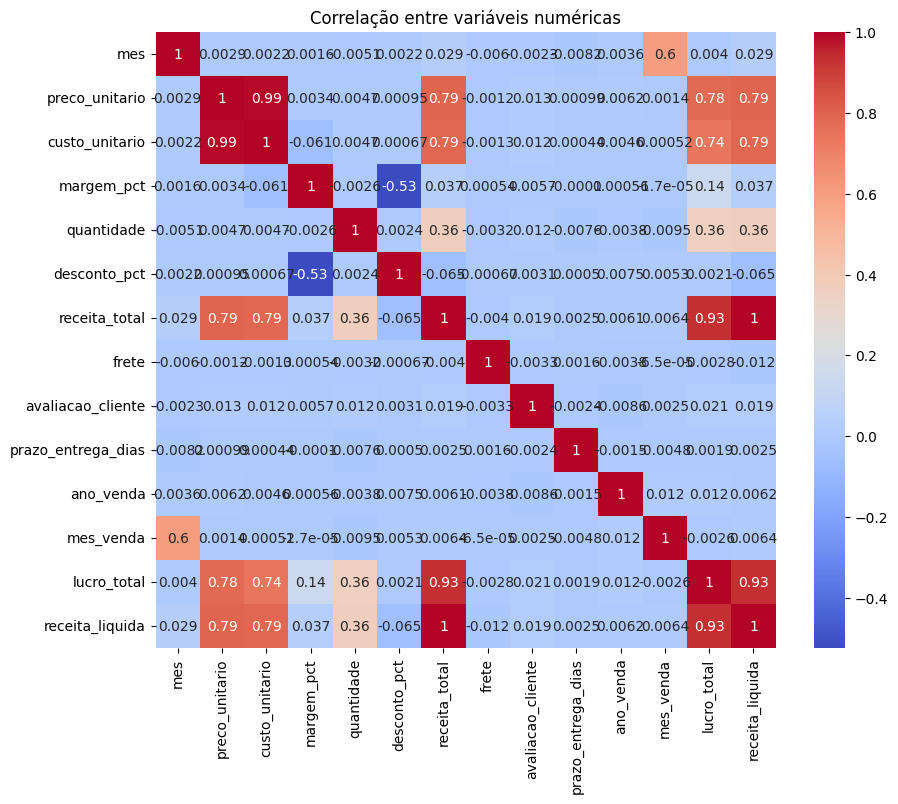

In [335]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre variáveis numéricas")

plt.show()

O mapa de calor permite identificar relações positivas e negativas entre as variáveis numéricas do conjunto de dados.

## Conclusão

Foram utilizadas bibliotecas fundamentais da Ciência de Dados para exploração, tratamento e análise das informações. O NumPy possibilitou operações vetorizadas eficientes, o Pandas facilitou a manipulação e transformação dos dados, enquanto o Seaborn permitiu visualizar padrões importantes nas vendas. Os resultados evidenciam diferenças de faturamento entre categorias, comportamento temporal das vendas e relações entre variáveis numéricas, demonstrando a utilidade dessas ferramentas em análises exploratórias.